In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## Membuka Dataset

In [2]:
data = pd.read_csv("HistoricalDailyWeatherRecords.csv")

# Cek struktur data
data.head()

,date,station,daily_rainfall_total,highest_30_min_rainfall,highest_60_min_rainfall,highest_120_min_rainfall,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
0,2009-01-01,Admiralty,na,na,na,na,na,na,na,na,na
1,2009-01-02,Admiralty,na,na,na,na,na,na,na,na,na
2,2009-01-03,Admiralty,na,na,na,na,na,na,na,na,na
3,2009-01-04,Admiralty,na,na,na,na,na,na,na,na,na
4,2009-01-05,Admiralty,na,na,na,na,na,na,na,na,na


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2859 entries, 0 to 2858
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   date                      2859 non-null   object
 1   station                   2859 non-null   object
 2   daily_rainfall_total      2859 non-null   object
 3   highest_30_min_rainfall   2859 non-null   object
 4   highest_60_min_rainfall   2859 non-null   object
 5   highest_120_min_rainfall  2859 non-null   object
 6   mean_temperature          2859 non-null   object
 7   maximum_temperature       2859 non-null   object
 8   minimum_temperature       2859 non-null   object
 9   mean_wind_speed           2859 non-null   object
 10  max_wind_speed            2859 non-null   object
dtypes: object(11)
memory usage: 245.8+ KB


## Data Exploration

In [4]:
# Cek missing values
data.replace('na', np.nan, inplace=True) # Mengubah data dengan value 'na' menjadi null value yang bisa dibaca python
print(data.isnull().sum())

date                           0
station                        0
daily_rainfall_total         105
highest_30_min_rainfall     1755
highest_60_min_rainfall     1755
highest_120_min_rainfall    1755
mean_temperature             139
maximum_temperature          115
minimum_temperature          115
mean_wind_speed               96
max_wind_speed                97
dtype: int64


In [5]:
# Cek tipe data

print(data.dtypes)

date                        object
station                     object
daily_rainfall_total        object
highest_30_min_rainfall     object
highest_60_min_rainfall     object
highest_120_min_rainfall    object
mean_temperature            object
maximum_temperature         object
minimum_temperature         object
mean_wind_speed             object
max_wind_speed              object
dtype: object


In [6]:
# Karena datatype masih tidak cocok, maka diconvert sesuai yang tertulis di website

for col in data.columns:
    if col == 'date':
        data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d', errors='coerce')
    elif col == 'station':
        data['station'] = data['station'].astype(str)
    else:
        data[col] = pd.to_numeric(data[col], errors='coerce')

print(data.dtypes)

date                        datetime64[ns]
station                             object
daily_rainfall_total               float64
highest_30_min_rainfall            float64
highest_60_min_rainfall            float64
highest_120_min_rainfall           float64
mean_temperature                   float64
maximum_temperature                float64
minimum_temperature                float64
mean_wind_speed                    float64
max_wind_speed                     float64
dtype: object


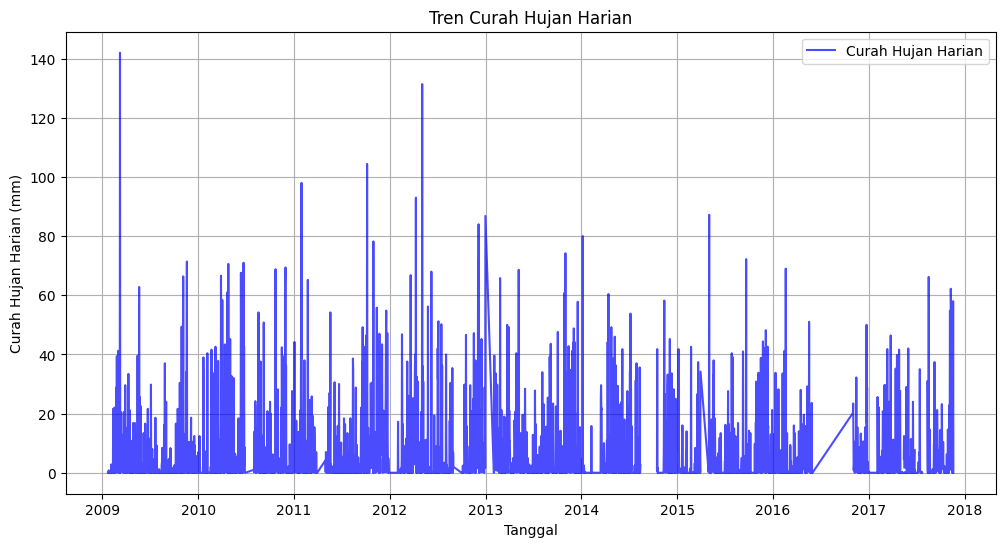

In [7]:
# Data Visualization

# Line plot untuk daily_rainfall_total terhadap waktu
plt.figure(figsize=(12, 6))
plt.plot(data['date'], data['daily_rainfall_total'], label='Curah Hujan Harian', color='blue', alpha=0.7)
plt.title('Tren Curah Hujan Harian')
plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan Harian (mm)')
plt.legend()
plt.grid()
plt.show()

In [8]:
data.describe()

,date,daily_rainfall_total,highest_30_min_rainfall,highest_60_min_rainfall,highest_120_min_rainfall,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
count,2859,2754.000000,1104.000000,1104.000000,1104.000000,2720.000000,2744.000000,2744.000000,2763.000000,2762.000000
mean,2013-04-19 15:08:07.303252736,6.591903,3.668478,4.478080,4.993569,27.632059,31.749052,24.959111,7.846073,34.689066
min,2009-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,23.300000,24.200000,21.600000,3.700000,11.500000
25%,2011-01-16 12:00:00,0.000000,0.000000,0.000000,0.000000,26.800000,30.700000,24.200000,6.100000,28.400000
50%,2013-05-02 00:00:00,0.200000,0.200000,0.200000,0.200000,27.600000,32.000000,24.900000,7.100000,33.500000
75%,2015-06-15 12:00:00,6.800000,3.850000,4.400000,5.000000,28.500000,33.000000,25.700000,8.900000,39.200000
max,2017-11-30 00:00:00,142.000000,47.800000,57.400000,80.800000,30.800000,36.600000,28.500000,18.700000,86.800000
std,NaN,13.335983,7.119767,8.947346,10.102011,1.186947,1.772685,1.205388,2.437322,8.537456


## Data Cleaning

Untuk highest_30_min_rainfall, highest_60_min_rainfall, dan highest_120_min_rainfall akan kita hapus karena terlalu banyak data yang hilang

In [9]:
removed_columns = ['highest_30_min_rainfall', 'highest_60_min_rainfall', 'highest_120_min_rainfall']
data_clean = data.drop(columns=removed_columns)
data_clean.head()

,date,station,daily_rainfall_total,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
0,2009-01-01,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN


Untuk sisanya, akan kita isi dengan methode forward fill dan backward fill. Ini dilakukan karena data berupa time series

In [10]:
numerical_columns = data_clean.select_dtypes(include=[np.number]).columns.tolist()
data_clean[numerical_columns] = data_clean[numerical_columns].ffill()
data_clean[numerical_columns] = data_clean[numerical_columns].bfill()
data_clean.isnull().sum()

date                    0
station                 0
daily_rainfall_total    0
mean_temperature        0
maximum_temperature     0
minimum_temperature     0
mean_wind_speed         0
max_wind_speed          0
dtype: int64

In [11]:
data_clean.head()

,date,station,daily_rainfall_total,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
0,2009-01-01,Admiralty,0.0,26.8,31.5,23.3,11.1,31.7
1,2009-01-02,Admiralty,0.0,26.8,31.5,23.3,11.1,31.7
2,2009-01-03,Admiralty,0.0,26.8,31.5,23.3,11.1,31.7
3,2009-01-04,Admiralty,0.0,26.8,31.5,23.3,11.1,31.7
4,2009-01-05,Admiralty,0.0,26.8,31.5,23.3,11.1,31.7


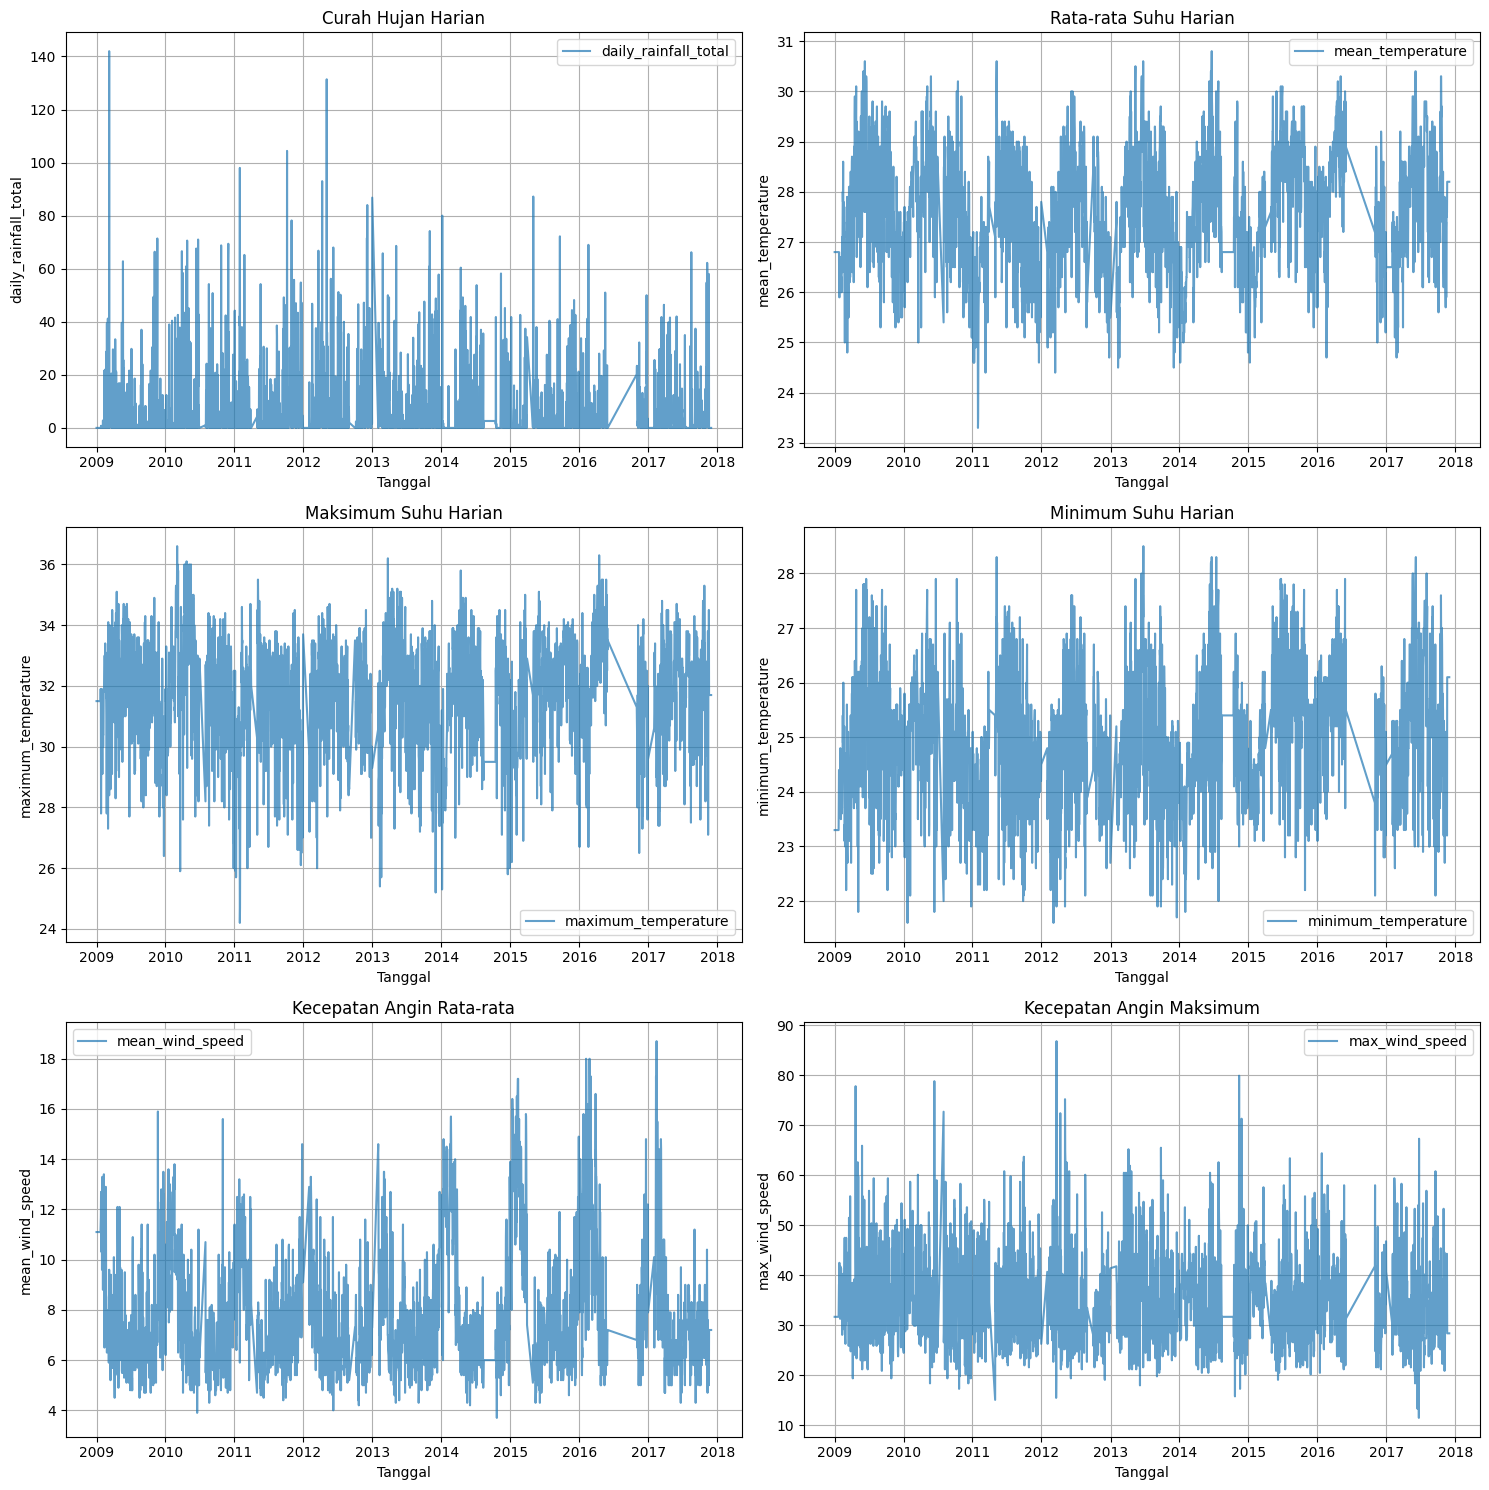

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))  # Create a 3x2 grid of subplots

columns_to_plot = numerical_columns  # Use the numerical columns for plotting
titles = [
    "Curah Hujan Harian",
    "Rata-rata Suhu Harian",
    "Maksimum Suhu Harian",
    "Minimum Suhu Harian",
    "Kecepatan Angin Rata-rata",
    "Kecepatan Angin Maksimum",
]

for ax, col, title in zip(axes.flatten(), columns_to_plot, titles):
    ax.plot(data_clean['date'], data_clean[col], label=col, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Tanggal")
    ax.set_ylabel(col)
    ax.legend()
    ax.grid()

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

In [22]:
def split_data(data, test_size=0.2):
    """
    Splits the data into training and testing sets.
    
    Parameters:
    - data: DataFrame to be split
    - test_size: Proportion of the data to be used for testing
    
    Returns:
    - train_data: Training set
    - test_data: Testing set
    """
    train_size = int(len(data) * (1 - test_size))
    train_data = data[:train_size]
    test_data = data[train_size:]
    
    return train_data, test_data

In [24]:
X, y = split_data(data_clean, test_size=0.2)
X.head(), y.head()

(        date    station  daily_rainfall_total  mean_temperature  \
 0 2009-01-01  Admiralty                   0.0              26.8   
 1 2009-01-02  Admiralty                   0.0              26.8   
 2 2009-01-03  Admiralty                   0.0              26.8   
 3 2009-01-04  Admiralty                   0.0              26.8   
 4 2009-01-05  Admiralty                   0.0              26.8   
 
    maximum_temperature  minimum_temperature  mean_wind_speed  max_wind_speed  
 0                 31.5                 23.3             11.1            31.7  
 1                 31.5                 23.3             11.1            31.7  
 2                 31.5                 23.3             11.1            31.7  
 3                 31.5                 23.3             11.1            31.7  
 4                 31.5                 23.3             11.1            31.7  ,
            date    station  daily_rainfall_total  mean_temperature  \
 2287 2015-11-06  Admiralty           